# Introduction to Decision Trees 

In this notebook we will get a feel for what types of predictions decision tree make by exploring performance with the Iris Dataset.

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn import tree
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.model_selection import train_test_split

%matplotlib inline

## Iris Dataset

To explore decision trees, we can start by taking look at the same simple dataset we did with KNNs yesterday -- the Iris Dataset. Let's import the data and print a few reminders.

In [15]:
# get data and print information about it 
from sklearn import datasets

iris = datasets.load_iris() # get data

print('The iris.data has {} samples each of which has {} features. e.g. first two data: {}'
      .format(iris.data.shape[0], iris.data.shape[1], iris.data[:2]))
print('The iris.target has labels (one of {}) for {} samples. e.g. first two labels {}'
      .format(iris.target_names, iris.target.shape[0], iris.target[:2]))


#print(iris.DESCR)

The iris.data has 150 samples each of which has 4 features. e.g. first two data: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]]
The iris.target has labels (one of ['setosa' 'versicolor' 'virginica']) for 150 samples. e.g. first two labels [0 0]


Next we define our features (X) and targets (y) for our model and plot the data.  Note that we again are only going to use the features Sepal width and Sepal length. The intention is that having a low dimensional example where we can visualize our decision boundary will help us get an intuitive feel for how decision trees make predictions.

In [3]:
X = iris.data[:, :2]  # we only take the first two features.
y = iris.target

### Plot Data

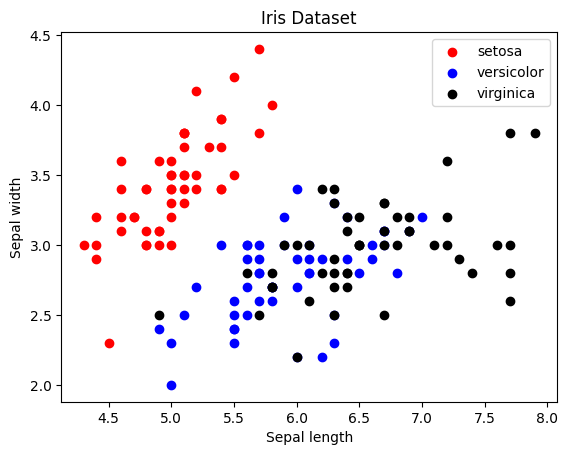

In [4]:
color_list_bold = [ '#FF0000', '#0000FF', '#000000']
labels={0:'setosa',1:'versicolor',2:'virginica'}
fig,ax=plt.subplots()
for i in range(3):
    ax.scatter(X[y==i, 0], X[y==i, 1],label=labels[i],color=color_list_bold[i])
ax.set_xlabel('Sepal length')
ax.set_ylabel('Sepal width')
ax.set_title('Iris Dataset')
ax.legend();

## Build Decision Tree Model 

Next, we will build and evaluate our first decision tree model.  The code below:
1. performs a test train split
2. trains the decision tree model
3. evaluated the model on train and test data. 

In [5]:
# test / train split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state = 0)

# instantiate and train DT model
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train,y_train)

# evaluate model on train and test data with accuracy 
print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))

Accuracy of K-NN classifier on training set: 0.93
Accuracy of K-NN classifier on test set: 0.67


There are tools within `scikit-learn` that allow us to visualize the decision tree and understand how our model is making predictions. 

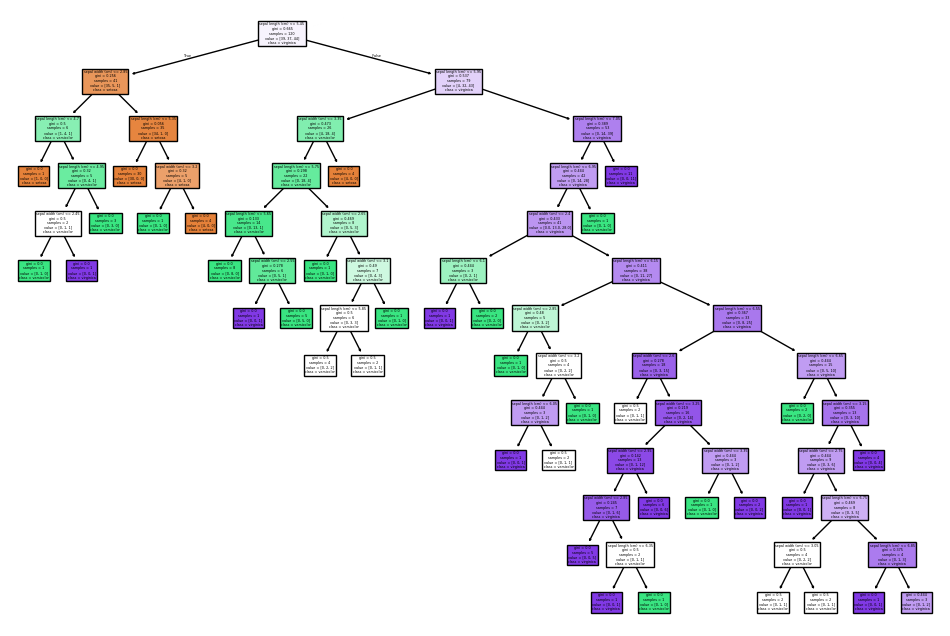

In [6]:
plt.figure(figsize=(12, 8)) 
feature_names=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
class_names=['setosa', 'versicolor', 'virginica']
tree.plot_tree(clf,
    feature_names=feature_names, 
    class_names=class_names,
    filled = True)
plt.show()

Additionally, we have some helper functions (similar to the KNN material) that will allow use to visualize the decision boundary.

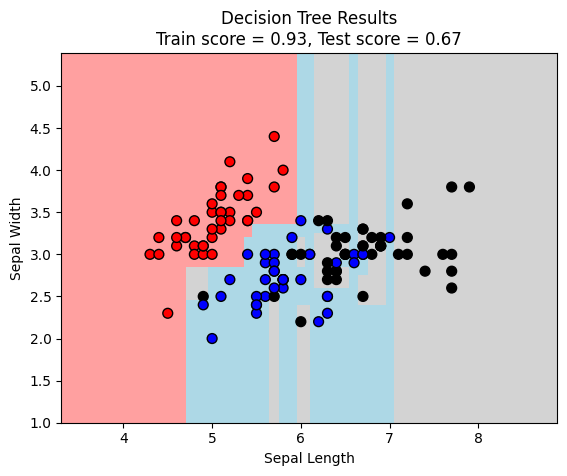

In [7]:
from plotting_dt import *

plot_two_class_dt(X_train, y_train, clf, X_test, y_test)

Let's put all of this into a function for later in this notebooks

In [8]:
def evaluate_dt(clf):
    print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
    print('Accuracy of K-NN classifier on test set: {:.2f}'
         .format(clf.score(X_test, y_test)))
    
    plt.figure(figsize=(12, 8)) 
    feature_names=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
    class_names=['setosa', 'versicolor', 'virginica']
    tree.plot_tree(clf,
        feature_names=feature_names, 
        class_names=class_names,
        filled = True)
    plt.show()
    
    plot_two_class_dt(X_train, y_train, clf, X_test, y_test)

The above decision boundaries is what a typical decision tree model looks like for classification problems.  The above example is also a classic example of over fitting, the model is going out of its way to generalize 

# Decision Tree Hyperparameters 

There are several hyperparameters we can use to deal with decision trees being prone to over fitting.  Here are a few examples of parameters we can change in sklearn to imporove performance:

1. **criterion** {“gini”, “entropy”, “log_loss”}, default=”gini” (As discussed in lecture)
2. **splitter** {“best”, “random”}, default=”best” ("best" is greedy algorithm, where as "random is typically used in ensemble methods)
3. **max_depth** int, default=None: The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
4. **min_samples_split** int or float, default=2: The minimum number of samples required to split an internal node: If int, then consider min_samples_split as the minimum number.
5. **min_samples_leaf** int or float, default=1: The minimum number of samples required to be at a leaf node.

Find more example hyperparameters in [sklearns documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

## Max Depth

Accuracy of K-NN classifier on training set: 0.79
Accuracy of K-NN classifier on test set: 0.57


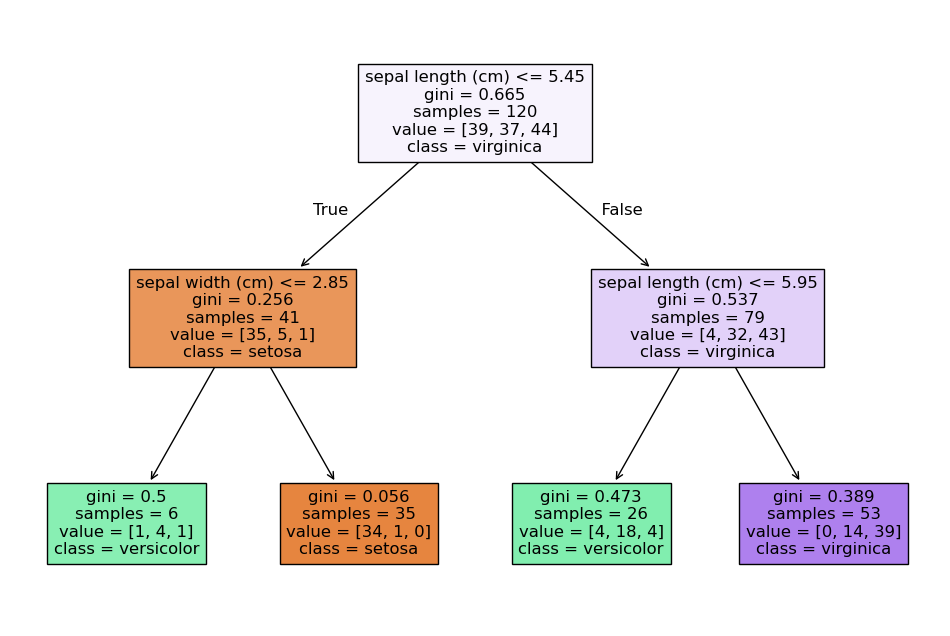

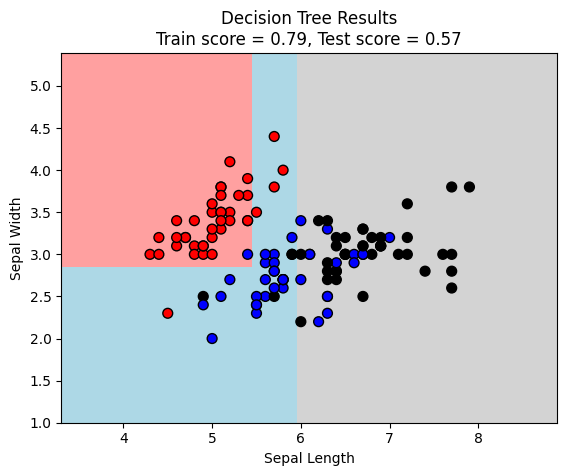

In [9]:
clf = tree.DecisionTreeClassifier(max_depth=2)
clf = clf.fit(X_train,y_train)

evaluate_dt(clf)

## min_samples_leaf

Accuracy of K-NN classifier on training set: 0.82
Accuracy of K-NN classifier on test set: 0.63


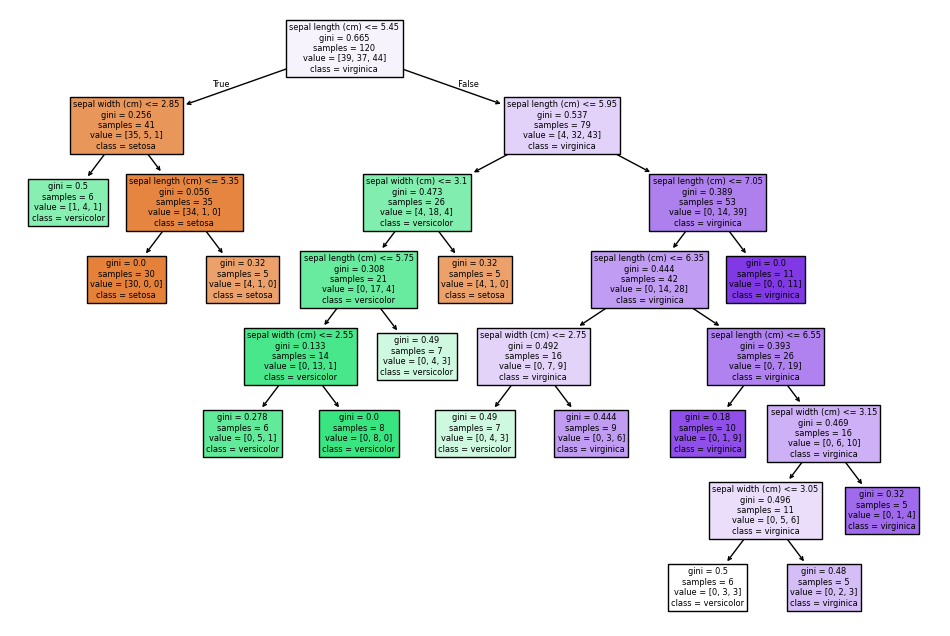

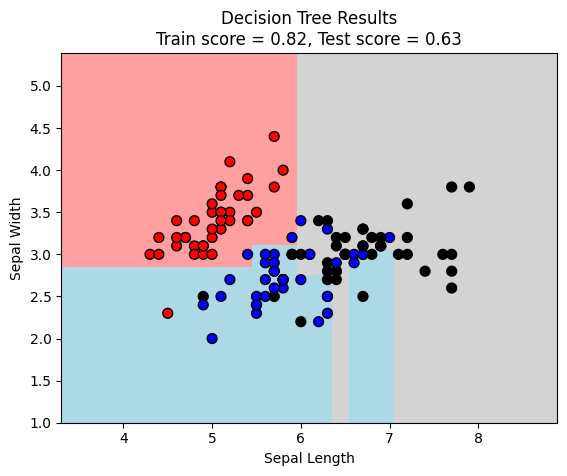

In [10]:
clf = tree.DecisionTreeClassifier(min_samples_leaf=5)
clf = clf.fit(X_train,y_train)

evaluate_dt(clf)

## Hyperparameter optimization

There are several hyperparameters to explore here! Thankfully sklearn has tools that perform hyperparameter optimization.  

Below we use the GridSearchCV to do hyperparameter optimization.  This use two primary techniques:

**Grid search**

There are a few ways these grid searches can be executed.  In the code below we will do a standard grid search

<img src="https://miro.medium.com/v2/resize:fit:781/1*8uSZqUSGa-UGF-0CDBd4Jw.png" width="600" />

**K Fold Cross Validation**

<img src="https://user-images.githubusercontent.com/5402633/156615870-b0244c46-2c16-432d-a3d7-9e7956828655.jpg"  width="600"/>

In [11]:
dt = tree.DecisionTreeClassifier()
param_grid = {
    'criterion': ['gini', 'entropy'],  # Splitting criteria
    'max_depth': [None, 5, 10, 15],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4]  # Minimum samples required at a leaf node
}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(dt,                    # model
                           param_grid,            # parameters to include in grid search
                           cv=5,                  # k in kfold cv
                           scoring='accuracy',    # evaluation metric
                           n_jobs=-1)             # number of jobs to run in parallel (-1 means use all processors)

grid_search.fit(X_train, y_train)

# Print the best parameters and corresponding accuracy score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Accuracy:", grid_search.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Cross-validation Accuracy: 0.7583333333333333


Accuracy of K-NN classifier on training set: 0.84
Accuracy of K-NN classifier on test set: 0.63


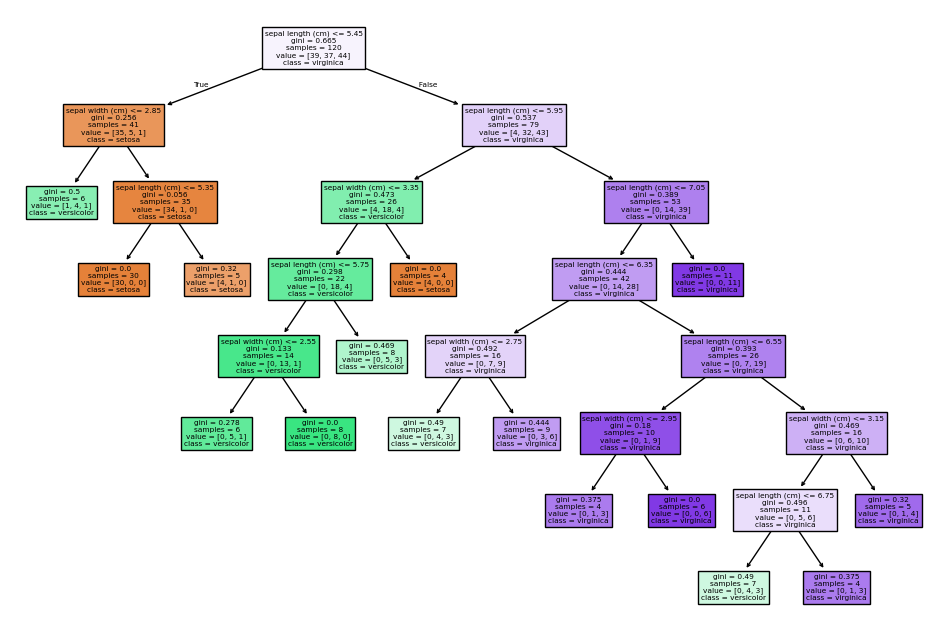

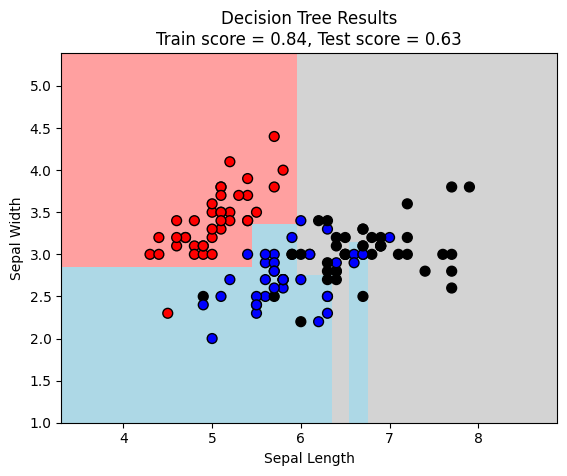

In [12]:
evaluate_dt(grid_search.best_estimator_)